In [1]:
# 日本語対応のモジュールをインストールする(その1)
!pip install japanize-matplotlib
# 日本語対応のモジュールをインストールする(その2)
!apt-get install -y fonts-ipafont-gothic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 56.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=b2368a1c075e2d425c6400956ffd788b958b18e0ca08626a751f61a2b14f63a3
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://ar

In [3]:
#各ライブラリーをインポートする
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
# データ読み込み
URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2023-06-29/data/listings.csv.gz"
df = pd.read_csv(URL, compression="gzip", low_memory=False)

# 価格の数値化
if df["price"].dtype == object:
    df["price"] = df["price"].str.replace(r"[\$,]", "", regex=True).astype(float)

# スーパーホストラベル(最後の発展課題でのみ使う。クラスタリングには使わない)
df["is_superhost"] = (df["host_is_superhost"] == "t").astype(int)

FEATURES = [
    "price", "number_of_reviews", "review_scores_rating",
    "accommodates", "bedrooms", "minimum_nights", "availability_365"
]

df_clean = df[FEATURES + ["is_superhost"]].dropna()

# 計算を軽くするためサンプリング(任意)
if len(df_clean) > 3000:
    df_clean = df_clean.sample(3000, random_state=42).reset_index(drop=True)

X = df_clean[FEATURES].values
y_sh = df_clean["is_superhost"].values # 発展課題用(クラスタリングには使わない)

print(f"データ準備完了: {len(df_clean):,}件、{len(FEATURES)} 変数")
print("※ クラスタリングは教師なし学習なので is_superhost は使わない")
print(" (最後の発展課題でのみ照合に使う)\n")

データ準備完了: 3,000件、7 変数
※ クラスタリングは教師なし学習なので is_superhost は使わない
 (最後の発展課題でのみ照合に使う)



In [5]:
# 標準化前の各変数のスケールを確認
print("── 標準化前の各変数のスケール ──")
scale_df = pd.DataFrame({
    "平均": df_clean[FEATURES].mean(),
    "標準偏差": df_clean[FEATURES].std(),
    "最大値": df_clean[FEATURES].max()
})
print(scale_df.round(1))

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

print("\n→ price (数千~数万)と review_scores_rating(0~5)では")
print(" スケールが全く違う。標準化しないと price だけで距離が決まる")
print("→ StandardScalerで平均0・分散1に揃える \n")

── 標準化前の各変数のスケール ──
                           平均     標準偏差        最大値
price                 21897.2  37950.2  1052387.0
number_of_reviews        41.9     58.0      799.0
review_scores_rating      4.7      0.4        5.0
accommodates              4.5      2.9       16.0
bedrooms                  1.5      1.0       11.0
minimum_nights            2.1      6.4      180.0
availability_365        141.4    101.8      365.0

→ price (数千~数万)と review_scores_rating(0~5)では
 スケールが全く違う。標準化しないと price だけで距離が決まる
→ StandardScalerで平均0・分散1に揃える 



In [6]:
# k-means
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X_sc)

df_clean["cluster_km"] = labels_km

print("── 各クラスタのサイズ ──")
print(pd.Series(labels_km).value_counts().sort_index())
print(f"\nInertia（クラスタ内誤差平方和）: {km.inertia_:.1f}")

# 各クラスタの特徴（元のスケールで平均を確認）
print("\n── 各クラスタの特徴（変数ごとの平均）──")
cluster_summary = df_clean.groupby("cluster_km")[FEATURES].mean()
print(cluster_summary.round(1).to_string())

── 各クラスタのサイズ ──
0    2486
1     507
2       7
Name: count, dtype: int64

Inertia（クラスタ内誤差平方和）: 13555.0

── 各クラスタの特徴（変数ごとの平均）──
               price  number_of_reviews  review_scores_rating  accommodates  bedrooms  minimum_nights  availability_365
cluster_km                                                                                                             
0            16812.3               36.1                   4.6           3.5       1.1             1.9             142.7
1            38435.6               70.9                   4.7           9.5       3.1             2.0             134.7
2           629892.1               20.6                   4.8           3.7       1.0           103.3             174.3


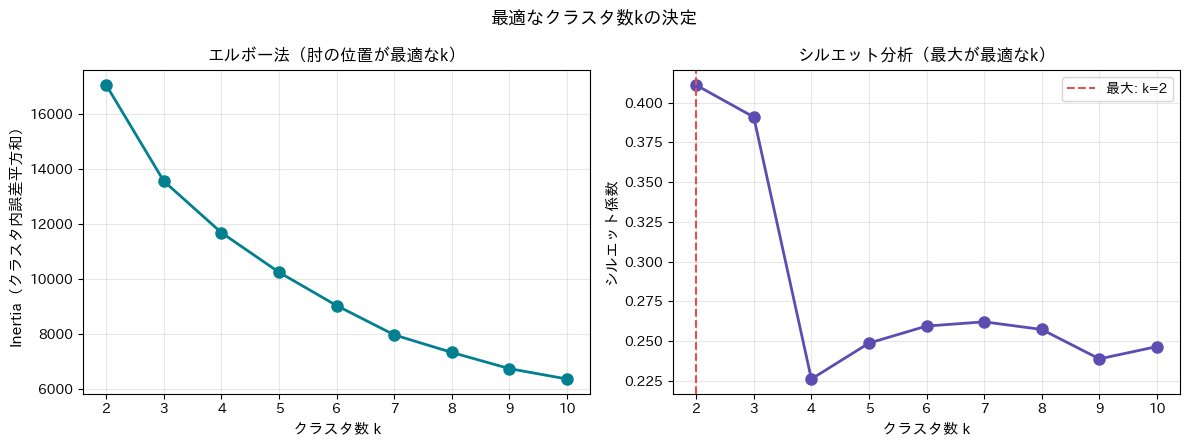


シルエット係数が最大のk: 2
各kのシルエット係数:
 k=2: 0.411 ← 最大
 k=3: 0.391
 k=4: 0.226
 k=5: 0.249
 k=6: 0.260
 k=7: 0.262
 k=8: 0.257
 k=9: 0.239
 k=10: 0.247


In [7]:
# 最適なクラスタ数kの決定
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km_k.fit_predict(X_sc)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X_sc, lab))

# グラフのプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, "o-", color="#028090", linewidth=2, markersize=8)
axes[0].set_xlabel("クラスタ数 k", fontsize=11)
axes[0].set_ylabel("Inertia（クラスタ内誤差平方和）", fontsize=11)
axes[0].set_title("エルボー法（肘の位置が最適なk）", fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, "o-", color="#5C4DB1", linewidth=2, markersize=8)
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(x=best_k, color="#E05252", linestyle="--", label=f"最大: k={best_k}")
axes[1].set_xlabel("クラスタ数 k", fontsize=11)
axes[1].set_ylabel("シルエット係数", fontsize=11)
axes[1].set_title("シルエット分析（最大が最適なk）", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("最適なクラスタ数kの決定", fontsize=13)
plt.tight_layout()
plt.savefig("choose_k.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nシルエット係数が最大のk: {best_k}")
print("各kのシルエット係数:")
for k, sil in zip(k_range, silhouettes):
    mark = " ← 最大" if k == best_k else ""
    print(f" k={k}: {sil:.3f}{mark}")

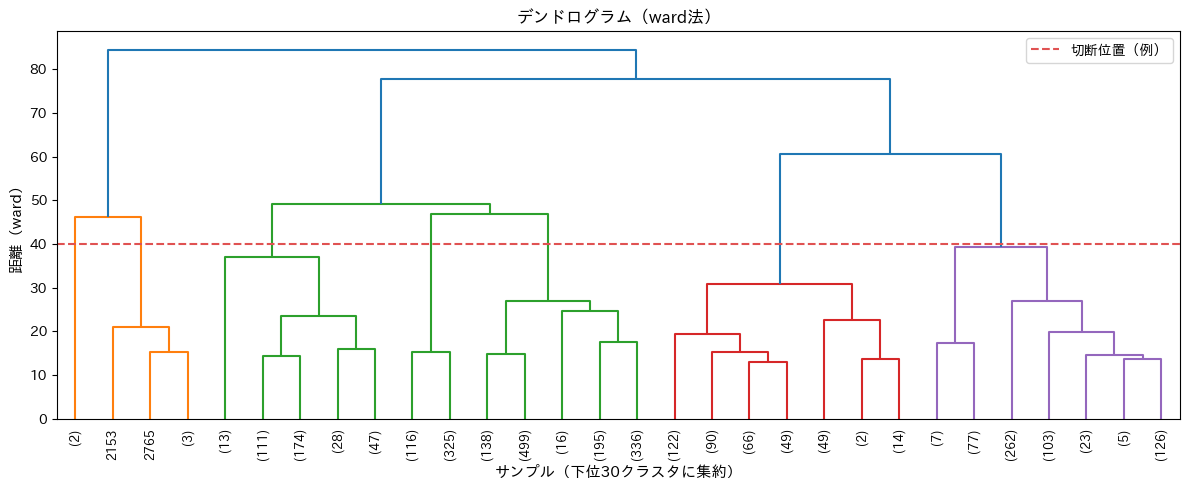


── 階層的クラスタリング（3クラスタ）のサイズ ──
0     995
1       7
2    1998
Name: count, dtype: int64

── k-means と階層的クラスタリングの一致度 ──
調整ランド指数（ARI）: 0.408
 （1に近いほど2つのクラスタリング結果が一致）


In [8]:
# デンドログラムと階層的クラスタリング
# ward法で連結
Z = linkage(X_sc, method="ward")

# デンドログラムの描画
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.axhline(y=40, color="#E05252", linestyle="--", linewidth=1.5, label="切断位置（例）")
plt.xlabel("サンプル（下位30クラスタに集約）", fontsize=11)
plt.ylabel("距離（ward）", fontsize=11)
plt.title("デンドログラム（ward法）", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

# 3クラスタに分割
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_hc = agg.fit_predict(X_sc)
df_clean["cluster_hc"] = labels_hc

print("\n── 階層的クラスタリング（3クラスタ）のサイズ ──")
print(pd.Series(labels_hc).value_counts().sort_index())

# k-meansとの比較
print("\n── k-means と階層的クラスタリングの一致度 ──")
ari = adjusted_rand_score(labels_km, labels_hc)
print(f"調整ランド指数（ARI）: {ari:.3f}")
print(" （1に近いほど2つのクラスタリング結果が一致）")

In [9]:
# DBSCAN（クラスタ数を指定しない）
db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X_sc)
df_clean["cluster_db"] = labels_db

# ラベル -1 はノイズ（外れ値）
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print(f"── DBSCAN（eps=0.5, min_samples=5）──")
print(f"検出されたクラスタ数: {n_clusters}")
print(f"ノイズ（外れ値）の数: {n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

# epsを変えて結果を比較
print("\n── epsを変えたときの結果 ──")
for eps in [0.3, 0.5, 0.8, 1.2, 1.5]:
    db_e = DBSCAN(eps=eps, min_samples=5)
    lab_e = db_e.fit_predict(X_sc)
    nc = len(set(lab_e)) - (1 if -1 in lab_e else 0)
    nn = list(lab_e).count(-1)
    print(f" eps={eps}: クラスタ{nc}個, ノイズ{nn}件 ({nn/len(lab_e)*100:.1f}%)")

── DBSCAN（eps=0.5, min_samples=5）──
検出されたクラスタ数: 17
ノイズ（外れ値）の数: 981 (32.7%)

── epsを変えたときの結果 ──
 eps=0.3: クラスタ38個, ノイズ2090件 (69.7%)
 eps=0.5: クラスタ17個, ノイズ981件 (32.7%)
 eps=0.8: クラスタ7個, ノイズ406件 (13.5%)
 eps=1.2: クラスタ4個, ノイズ144件 (4.8%)
 eps=1.5: クラスタ3個, ノイズ61件 (2.0%)


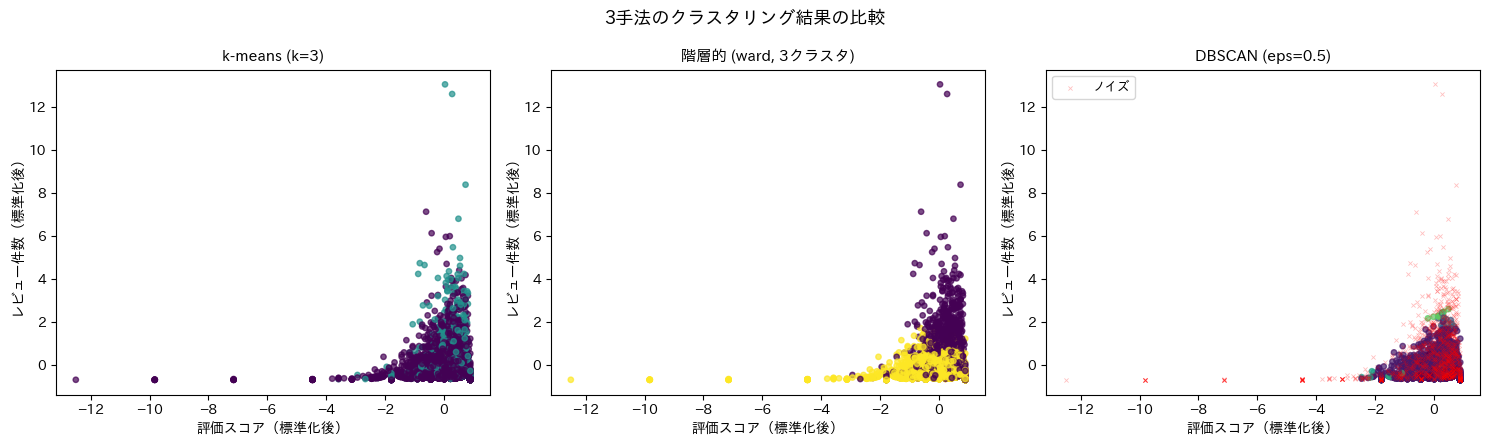

In [10]:
# 可視化用に2変数を選ぶ（レビュースコアとレビュー件数）
ix_x = FEATURES.index("review_scores_rating")
ix_y = FEATURES.index("number_of_reviews")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, labels, title in [
    (axes[0], labels_km, "k-means (k=3)"),
    (axes[1], labels_hc, "階層的 (ward, 3クラスタ)"),
    (axes[2], labels_db, "DBSCAN (eps=0.5)"),
]:
    is_noise = labels == -1
    # クラスタ点（ノイズ以外）を先に・はっきり描く
    ax.scatter(X_sc[~is_noise, ix_x], X_sc[~is_noise, ix_y], c=labels[~is_noise], cmap="viridis", s=15, alpha=0.7)

    # ノイズは薄く・小さく、1回だけ重ねる
    if is_noise.any():
        ax.scatter(X_sc[is_noise, ix_x], X_sc[is_noise, ix_y], c="red", s=9, marker="x", linewidths=0.6, alpha=0.25, label="ノイズ")
        ax.legend(fontsize=9)

    ax.set_xlabel("評価スコア（標準化後）", fontsize=10)
    ax.set_ylabel("レビュー件数（標準化後）", fontsize=10)
    ax.set_title(title, fontsize=11)

plt.suptitle("3手法のクラスタリング結果の比較", fontsize=13)
plt.tight_layout()
plt.savefig("three_methods.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# k-meansのクラスタとSHラベルのクロス集計
cross = pd.crosstab(
    df_clean["cluster_km"],
    df_clean["is_superhost"],
    rownames=["k-meansクラスタ"],
    colnames=["スーパーホスト"]
)
print("── クラスタ × スーパーホストのクロス集計 ──")
print(cross.to_string())

# 各クラスタのSH比率
print("\n── 各クラスタのスーパーホスト比率 ──")
sh_ratio = df_clean.groupby("cluster_km")["is_superhost"].mean()
for c, ratio in sh_ratio.items():
    print(f" クラスタ{c}: SH比率 {ratio:.1%}")

print(f"\n全体のSH比率: {df_clean['is_superhost'].mean():.1%}")
print("\n→ クラスタによってSH比率に偏りがあれば、")
print(" 教師なし学習が教師ありラベルの構造を部分的に捉えている")

── クラスタ × スーパーホストのクロス集計 ──
スーパーホスト         0    1
k-meansクラスタ           
0            1770  716
1             313  194
2               7    0

── 各クラスタのスーパーホスト比率 ──
 クラスタ0: SH比率 28.8%
 クラスタ1: SH比率 38.3%
 クラスタ2: SH比率 0.0%

全体のSH比率: 30.3%

→ クラスタによってSH比率に偏りがあれば、
 教師なし学習が教師ありラベルの構造を部分的に捉えている
